In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    roc_auc_score, roc_curve, f1_score
)
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42

Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26 

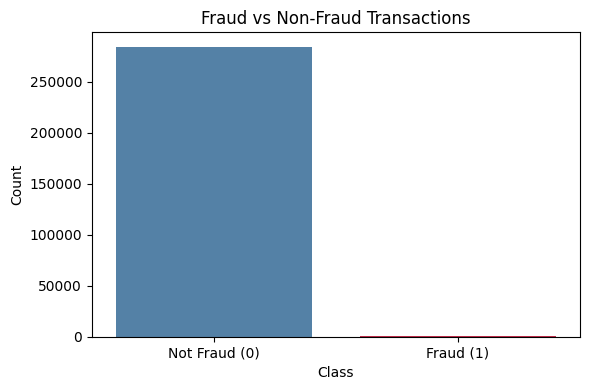


Top features correlated with fraud:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
Name: Class, dtype: float64

Bottom features (negative correlation):
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


In [3]:
df = pd.read_csv('creditcard.csv')

print("Shape:", df.shape)
print(df.head())
print("\n=== Missing Values ===")
print(df.isnull().sum().sum(), "total missing values")

fraud_count = df['Class'].value_counts()
print("\nClass distribution:")
print(fraud_count)
print(f"Fraud percentage: {fraud_count[1] / len(df) * 100:.4f}%")

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette=['steelblue', 'crimson'])
plt.title('Fraud vs Non-Fraud Transactions')
plt.xticks([0, 1], ['Not Fraud (0)', 'Fraud (1)'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('01_class_distribution1.png', dpi=150)
plt.show()
plt.close()

correlations = df.corr()['Class'].sort_values(ascending=False)
print("\nTop features correlated with fraud:")
print(correlations.head(6))
print("\nBottom features (negative correlation):")
print(correlations.tail(6))

In [6]:
# ======================================================================
# 3. DETERMINISTIC FEATURE ENGINEERING (safe pre-split — each value
#    depends only on that row, not on any dataset-wide statistic)
# ======================================================================
df['hour'] = (df['Time'] // 3600) % 24
df['log_amount'] = np.log1p(df['Amount'])

# Simulated merchant-category risk feed. 
np.random.seed(RANDOM_STATE)
merchant_risk_map = {i: np.random.uniform(0.01, 0.5) for i in range(24)}
df['merchant_risk_score'] = df['hour'].map(merchant_risk_map)

In [7]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Fraud in train: {y_train.sum()} | Fraud in test: {y_test.sum()}")


Train: (227845, 33) | Test: (56962, 33)
Fraud in train: 394 | Fraud in test: 98


In [8]:
amount_scaler = StandardScaler()
time_scaler = StandardScaler()

X_train['scaled_Amount'] = amount_scaler.fit_transform(X_train[['Amount']])
X_test['scaled_Amount'] = amount_scaler.transform(X_test[['Amount']])

X_train['scaled_Time'] = time_scaler.fit_transform(X_train[['Time']])
X_test['scaled_Time'] = time_scaler.transform(X_test[['Time']])

train_amount = X_train['Amount'].copy()
test_amount = X_test['Amount'].copy()

X_train.drop(['Amount', 'Time'], axis=1, inplace=True)
X_test.drop(['Amount', 'Time'], axis=1, inplace=True)

# 5b. Amount percentile rank — reference distribution built from TRAIN only
X_train['amount_rank'] = train_amount.rank(pct=True)
sorted_train_amounts = np.sort(train_amount.values)
X_test['amount_rank'] = np.searchsorted(
    sorted_train_amounts, test_amount.values, side='right'
) / len(sorted_train_amounts)

# 5c. High-value flag — threshold learned from TRAIN only
high_value_threshold = train_amount.quantile(0.95)
X_train['is_high_value'] = (train_amount > high_value_threshold).astype(int).values
X_test['is_high_value'] = (test_amount > high_value_threshold).astype(int).values

# 5d. Transaction velocity per hour — counts learned from TRAIN only
train_hourly_counts = X_train['hour'].value_counts()
X_train['txn_velocity_per_hour'] = X_train['hour'].map(train_hourly_counts)
X_test['txn_velocity_per_hour'] = X_test['hour'].map(train_hourly_counts).fillna(0)

# Drop merchant_risk_score before modeling — it's collinear with `hour`
X_train.drop('merchant_risk_score', axis=1, inplace=True)
X_test.drop('merchant_risk_score', axis=1, inplace=True)

print("\nFinal feature set:", list(X_train.columns))



Final feature set: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'hour', 'log_amount', 'scaled_Amount', 'scaled_Time', 'amount_rank', 'is_high_value', 'txn_velocity_per_hour']


In [9]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE — Not Fraud: {sum(y_train_sm == 0):,} | "
      f"Fraud: {sum(y_train_sm == 1):,}")
print(f"Test set (untouched) — Not Fraud: {(y_test == 0).sum():,} | "
      f"Fraud: {y_test.sum()}")


After SMOTE — Not Fraud: 227,451 | Fraud: 227,451
Test set (untouched) — Not Fraud: 56,864 | Fraud: 98



Logistic Regression
              precision    recall  f1-score   support

   Not Fraud       1.00      0.98      0.99     56864
       Fraud       0.07      0.91      0.13        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9662 | PR-AUC: 0.7290 | F1 (fraud class): 0.1254


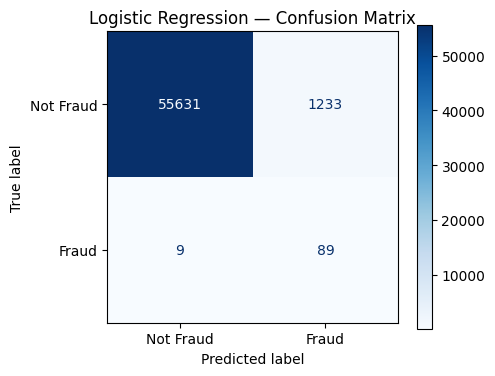


Random Forest
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.46      0.88      0.60        98

    accuracy                           1.00     56962
   macro avg       0.73      0.94      0.80     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9854 | PR-AUC: 0.8074 | F1 (fraud class): 0.6014


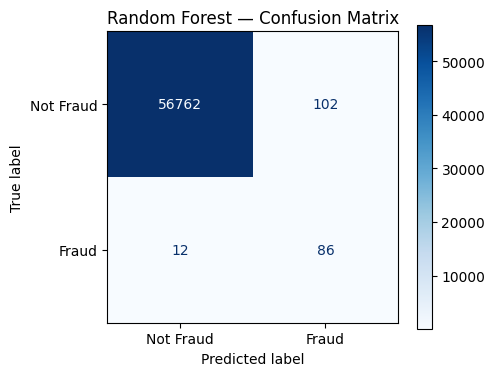

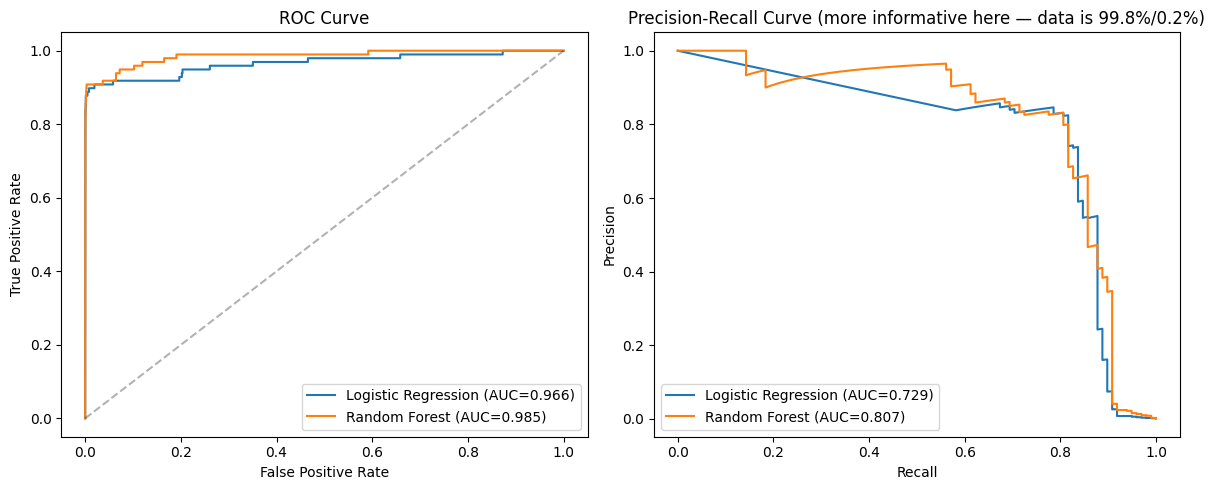

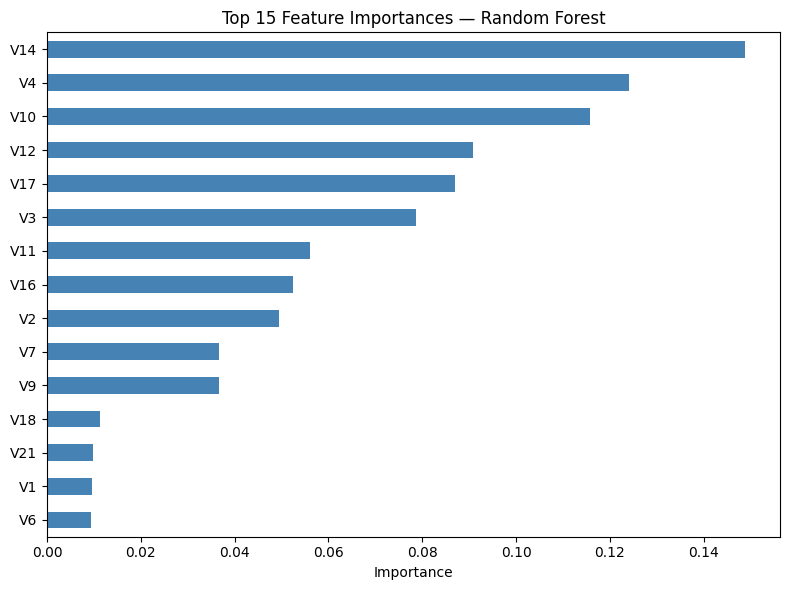


Top 15 features driving fraud predictions:
V14    0.148834
V4     0.124094
V10    0.115814
V12    0.090919
V17    0.087068
V3     0.078612
V11    0.056173
V16    0.052406
V2     0.049401
V7     0.036655
V9     0.036606
V18    0.011222
V21    0.009713
V1     0.009515
V6     0.009366
dtype: float64

FINAL SUMMARY
Model                 ROC-AUC     PR-AUC      F1 (fraud)  
Logistic Regression   0.9662      0.7290      0.1254      
Random Forest         0.9854      0.8074      0.6014      

Saved: 01_class_distribution.png, cm_logistic_regression.png, cm_random_forest.png, model_comparison_curves.png, feature_importance.png


In [11]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n{'=' * 60}\n{name}\n{'=' * 60}")
    print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))

    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    print(f"ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f} | F1 (fraud class): {f1:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=['Not Fraud', 'Fraud']).plot(ax=ax, cmap='Blues')
    ax.set_title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'cm_{name.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()
    plt.close()

    return {'name': name, 'roc_auc': roc_auc, 'pr_auc': pr_auc, 'f1': f1,
            'y_proba': y_proba}

# ======================================================================
# 8. MODEL 1 — Logistic Regression (fast, interpretable baseline)
# ======================================================================
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_sm, y_train_sm)
lr_results = evaluate_model("Logistic Regression", log_reg, X_test, y_test)

# ======================================================================
# 9. MODEL 2 — Random Forest (stronger, non-linear, gives feature importance)
# ======================================================================
rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=RANDOM_STATE,
    n_jobs=-1, class_weight=None  # class balance already handled by SMOTE
)
rf.fit(X_train_sm, y_train_sm)
rf_results = evaluate_model("Random Forest", rf, X_test, y_test)

# ======================================================================
# 10. MODEL COMPARISON — ROC and Precision-Recall curves side by side
# ======================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for res, model in [(lr_results, log_reg), (rf_results, rf)]:
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, label=f"{res['name']} (AUC={res['roc_auc']:.3f})")

    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    axes[1].plot(rec, prec, label=f"{res['name']} (AUC={res['pr_auc']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (more informative here — data is 99.8%/0.2%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_comparison_curves.png', dpi=150)
plt.show()
plt.close()

# ======================================================================
# 11. FEATURE IMPORTANCE (Random Forest)
# ======================================================================
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
plt.close()

print("\nTop 15 features driving fraud predictions:")
print(importances)

# ======================================================================
# 12. FINAL SUMMARY
# ======================================================================
print(f"\n{'=' * 60}\nFINAL SUMMARY\n{'=' * 60}")
print(f"{'Model':<22}{'ROC-AUC':<12}{'PR-AUC':<12}{'F1 (fraud)':<12}")
for res in [lr_results, rf_results]:
    print(f"{res['name']:<22}{res['roc_auc']:<12.4f}{res['pr_auc']:<12.4f}{res['f1']:<12.4f}")

print("\nSaved: 01_class_distribution.png, cm_logistic_regression.png, "
      "cm_random_forest.png, model_comparison_curves.png, feature_importance.png")
